# Latihan Mandiri (Tugas Praktikum #1)

**Mata Kuliah:** Pemrosesan Paralel
**Nama:** *(Hanifah Salsabila Zuheri)*
**NIM:** *(2411513016)*

## 1 — Klasifikasi Flynn

**a. Operasi `arr + arr` pada NumPy array**

Operasi ini dapat dikategorikan sebagai **SIMD** (Single Instruction, Multiple Data) karena satu instruksi, yaitu penjumlahan, dapat dilakukan pada beberapa elemen array secara bersamaan. Jadi, data tidak perlu diproses satu per satu menggunakan loop seperti pada Python biasa. NumPy juga dapat memanfaatkan kemampuan pemrosesan vektor yang tersedia pada prosesor, seperti AVX dan SSE, sehingga beberapa data dapat diproses dalam satu kali eksekusi. Hal ini sesuai dengan konsep SIMD yang termasuk dalam Taksonomi Flynn.

**b. Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris**

Jika program tidak menggunakan *threading* atau *multiprocessing*, maka prosesnya berjalan melalui satu alur eksekusi secara berurutan. Setiap baris file dibaca dan diproses satu per satu, sehingga data berikutnya baru akan diproses setelah data sebelumnya selesai. Cara kerja seperti ini termasuk **SISD** (*Single Instruction, Single Data*) karena satu instruksi hanya menangani satu data dalam satu waktu dan tidak terdapat proses paralel.

**c. Cluster komputer, yang masing-masing node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen**

**MIMD** (Multiple Instruction, Multiple Data) karena setiap node dalam cluster dapat menjalankan instruksi dan mengolah data yang berbeda sesuai dengan tugasnya masing-masing. Setiap node bekerja pada mesin yang terpisah, sehingga proses dapat berjalan secara bersamaan tanpa harus menunggu node lainnya selesai.

## 2 — Analisis Amdahl

Aplikasi pengolahan citra memiliki proporsi paralel $P = 0.85$ 

In [11]:
# Fungsi untuk menghitung speedup menggunakan Hukum Amdahl
def amdahl_speedup(P, N):
    return 1 / ((1 - P) + (P / N))


# Menentukan proporsi program yang dapat dijalankan secara paralel
P = 0.85

# Menentukan jumlah prosesor yang akan diuji
daftar_N = [2, 4, 8, 16, 32, 64]

# Menghitung batas maksimum speedup secara teoritis
speedup_maksimum = 1 / (1 - P)

# Menghitung speedup untuk setiap jumlah prosesor
daftar_speedup = [amdahl_speedup(P, N) for N in daftar_N]

# Menampilkan proporsi paralel dan serial
print(f"Proporsi paralel P = {P}  (proporsi serial 1-P = {1 - P:.2f})\n")

# Membuat tabel hasil
print(f"{'N':>4} | {'Speedup S(N)':>13} | {'% dari speedup maksimum':>24}")
print("-" * 48)

# Menampilkan hasil untuk setiap jumlah prosesor
for N, S in zip(daftar_N, daftar_speedup):
    persen = S / speedup_maksimum * 100
    print(f"{N:>4} | {S:>13.4f} | {persen:>23.1f}%")

# Menampilkan speedup maksimum teoritis
print(f"\nSpeedup maksimum teoritis (N -> tak hingga) = 1/(1-P) = {speedup_maksimum:.4f}x")

Proporsi paralel P = 0.85  (proporsi serial 1-P = 0.15)

   N |  Speedup S(N) |  % dari speedup maksimum
------------------------------------------------
   2 |        1.7391 |                    26.1%
   4 |        2.7586 |                    41.4%
   8 |        3.9024 |                    58.5%
  16 |        4.9231 |                    73.8%
  32 |        5.6637 |                    85.0%
  64 |        6.1244 |                    91.9%

Speedup maksimum teoritis (N -> tak hingga) = 1/(1-P) = 6.6667x


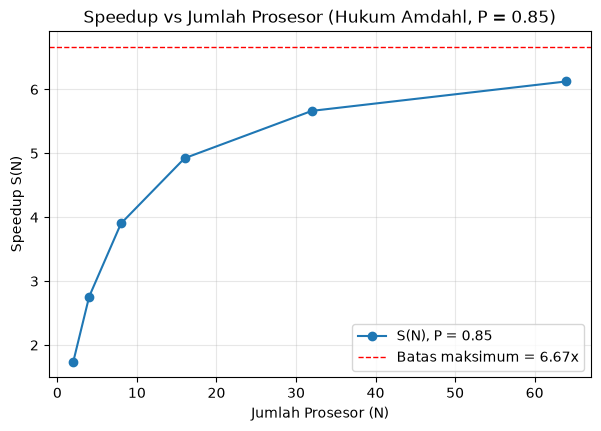

In [12]:
# Mengimpor library matplotlib untuk membuat grafik
import matplotlib.pyplot as plt

# Membuat ukuran area grafik
plt.figure(figsize=(7, 4.5))

# Membuat grafik hubungan jumlah prosesor dengan speedup
plt.plot(daftar_N, daftar_speedup, marker='o', label=f"S(N), P = {P}")

# Menambahkan garis batas maksimum speedup secara teoritis
plt.axhline(speedup_maksimum, color='red', linestyle='--', linewidth=1,
            label=f"Batas maksimum = {speedup_maksimum:.2f}x")

# Memberikan judul pada grafik
plt.title("Speedup vs Jumlah Prosesor (Hukum Amdahl, P = 0.85)")

# Memberikan nama pada sumbu X
plt.xlabel("Jumlah Prosesor (N)")

# Memberikan nama pada sumbu Y
plt.ylabel("Speedup S(N)")

# Menambahkan garis bantu pada grafik
plt.grid(alpha=0.3)

# Menampilkan keterangan grafik
plt.legend()

# Menampilkan grafik
plt.show()

**pada N berapa penambahan prosesor mulai memberikan manfaat yang sangat kecil (diminishing returns) jelaskan alasan kalian**

Penambahan prosesor mulai memberikan manfaat yang sangat kecil (diminishing returns) pada sekitar N = 32 prosesor. Hal ini dapat dilihat dari peningkatan speedup yang semakin kecil ketika jumlah prosesor ditambah. Dari 32 menjadi 64 prosesor, jumlah prosesor meningkat dua kali lipat, tetapi speedup hanya naik dari sekitar 5,66× menjadi 6,12×. Kondisi ini terjadi karena masih terdapat 15% bagian program yang bersifat serial, sehingga peningkatan jumlah prosesor memiliki pengaruh yang semakin kecil dan speedup akhirnya mendekati batas maksimum teoritis sebesar 6,67×.

## 3 — Benchmark Mandiri

In [8]:
# Membuat fungsi untuk menghitung suku Fibonacci secara rekursif
def fibonacci_rekursif(n):

    # Jika n bernilai 0 atau 1, langsung mengembalikan nilai n
    if n <= 1:
        return n

    # Menghitung Fibonacci dengan menjumlahkan dua suku sebelumnya
    return fibonacci_rekursif(n - 1) + fibonacci_rekursif(n - 2)


# Menguji fungsi dengan menghitung 10 suku pertama deret Fibonacci
print([fibonacci_rekursif(i) for i in range(10)])

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]


In [6]:
# Mengimpor modul time untuk mengukur waktu eksekusi program
import time

# Menentukan beberapa ukuran input yang akan diuji
ukuran_input = [25, 28, 30, 32]

# Menyiapkan list untuk menyimpan hasil waktu eksekusi
waktu_perf_counter = []

# Membuat judul tabel hasil pengukuran
print(f"{'N':>4} | {'Waktu perf_counter':>19}")
print("-" * 28)

# Mengukur waktu eksekusi Fibonacci untuk setiap ukuran input
for n in ukuran_input:

    # Mencatat waktu sebelum fungsi dijalankan
    start = time.perf_counter()

    # Menjalankan fungsi Fibonacci rekursif dengan nilai n
    fibonacci_rekursif(n)

    # Menghitung lama waktu yang dibutuhkan untuk menjalankan fungsi
    durasi = time.perf_counter() - start

    # Menyimpan hasil pengukuran waktu ke dalam list
    waktu_perf_counter.append(durasi)

    # Menampilkan waktu eksekusi untuk setiap nilai n
    print(f"{n:>4} | {durasi:>18.4f}s")

   N |  Waktu perf_counter
----------------------------
  25 |             0.0372s
  28 |             0.1267s
  30 |             0.3530s
  32 |             0.9956s


In [7]:
# Mengimpor modul timeit untuk mengukur waktu eksekusi program
import timeit

# Menyiapkan list untuk menyimpan hasil waktu terbaik
waktu_timeit = []

# Membuat judul tabel hasil pengukuran
print(f"{'N':>4} | {'Waktu timeit (terbaik dari 3)':>30}")
print("-" * 40)

# Mengukur waktu eksekusi untuk setiap ukuran input
for n in ukuran_input:

    # Menjalankan fungsi Fibonacci sebanyak 3 kali untuk mendapatkan beberapa hasil pengukuran
    hasil = timeit.repeat(
        stmt=f"fibonacci_rekursif({n})",
        globals=globals(),
        number=1,
        repeat=3
    )

    # Mengambil waktu tercepat dari 3 kali pengukuran
    terbaik = min(hasil)

    # Menyimpan waktu terbaik ke dalam list
    waktu_timeit.append(terbaik)

    # Menampilkan hasil waktu terbaik untuk setiap nilai n
    print(f"{n:>4} | {terbaik:>29.4f}s")

   N |  Waktu timeit (terbaik dari 3)
----------------------------------------
  25 |                        0.0306s
  28 |                        0.1268s
  30 |                        0.3718s
  32 |                        1.0531s


   N |  perf_counter (s) |   timeit (s) |  selisih (s)
-------------------------------------------------------
  25 |            0.0372 |       0.0306 |       0.0066
  28 |            0.1267 |       0.1268 |       0.0001
  30 |            0.3530 |       0.3718 |       0.0188
  32 |            0.9956 |       1.0531 |       0.0575


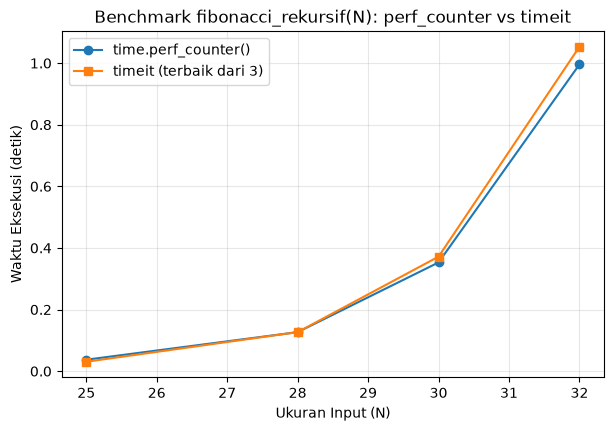

In [10]:
# Membuat judul tabel untuk membandingkan hasil kedua pengukuran
print(f"{'N':>4} | {'perf_counter (s)':>17} | {'timeit (s)':>12} | {'selisih (s)':>12}")
print("-" * 55)

# Membandingkan waktu eksekusi dari perf_counter dan timeit untuk setiap nilai N
for n, tp, tt in zip(ukuran_input, waktu_perf_counter, waktu_timeit):

    # Menampilkan waktu dari kedua metode serta selisih waktunya
    print(f"{n:>4} | {tp:>17.4f} | {tt:>12.4f} | {abs(tp - tt):>12.4f}")


# Membuat area grafik
plt.figure(figsize=(7, 4.5))

# Membuat grafik hasil pengukuran menggunakan perf_counter
plt.plot(ukuran_input, waktu_perf_counter, marker='o', label='time.perf_counter()')

# Membuat grafik hasil pengukuran menggunakan timeit
plt.plot(ukuran_input, waktu_timeit, marker='s', label='timeit (terbaik dari 3)')

# Memberikan judul pada grafik
plt.title("Benchmark fibonacci_rekursif(N): perf_counter vs timeit")

# Memberikan nama pada sumbu X
plt.xlabel("Ukuran Input (N)")

# Memberikan nama pada sumbu Y
plt.ylabel("Waktu Eksekusi (detik)")

# Menambahkan garis bantu pada grafik
plt.grid(alpha=0.3)

# Menampilkan keterangan untuk setiap garis pada grafik
plt.legend()

# Menampilkan grafik
plt.show()

Kedua alat ukur menunjukkan tren yang sama: ketika N naik, waktu eksekusinya meningkat jauh lebih besar, sesuai dengan sifat rekursi naif yang memiliki kompleksitas \(O(2^N)\). Dari N=30 ke N=32 misalnya, nilai N hanya naik 2, tetapi waktu eksekusinya meningkat lebih dari dua kali lipat. Selisih antara perf_counter dan timeit sendiri tidak terlalu besar, dengan selisih paling tinggi sekitar 0,007 detik pada N=32. Perbedaan ini masih wajar karena perf_counter pada pengukuran ini hanya mengukur satu kali eksekusi sehingga lebih mudah dipengaruhi oleh proses lain yang berjalan di sistem. Sementara itu, timeit melakukan tiga kali pengukuran dan mengambil waktu tercepat, sehingga pada hasil ini waktunya sedikit lebih rendah.

## 4 — Refleksi Singkat

Hukum Amdahl lebih relevan digunakan ketika ukuran masalah atau beban kerja relatif tetap dan kita ingin melihat seberapa besar peningkatan kinerja yang bisa diperoleh dengan menambah prosesor. Contohnya adalah server database yang menjalankan transaksi dengan ukuran beban yang relatif sama, sehingga bagian program yang tidak dapat diparalelkan menjadi batas utama speedup.

Sebaliknya, Hukum Gustafson lebih relevan ketika jumlah prosesor bertambah dan ukuran masalah juga dapat diperbesar, sehingga pekerjaan paralel yang lebih besar dapat dimanfaatkan. Contohnya adalah simulasi cuaca pada supercomputer, karena penambahan prosesor memungkinkan model menggunakan resolusi yang lebih tinggi dan memproses wilayah atau data yang lebih besar dalam waktu yang tetap masuk akal.